In [1]:
import pandas as pd
import numpy as np 
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn import preprocessing

# Read the data

In [2]:
df = pd.read_csv('Pooled_biochemdata_June9.csv',sep=',')

# Select all columns that are required for further processing

In [3]:
df=df[['Diagnosis','Age','Gender','HBV-Viral-load','AST','ALT','WBC','RBC','Platelets','Total-Bilirubin','DirectBili','Albumin','Prothrombin']]

In [4]:
df.head()

,Diagnosis,Age,Gender,HBV-Viral-load,AST,ALT,WBC,RBC,Platelets,Total-Bilirubin,DirectBili,Albumin,Prothrombin
0,HCC,51.0,Male,NaN,127.0,343.0,6.93,6.13,101,7.4,2.4,42.6,105.0
1,HCC,36.0,Male,NaN,42.0,37.0,3.95,4.63,104,15.7,7.0,42.3,85.0
2,HCC,48.0,Female,NaN,37.0,30.0,5.14,3.81,268,8.7,0.7,NaN,87.0
3,HCC,61.0,Male,NaN,84.0,45.0,7.74,5.32,219,25.3,5.7,NaN,105.0
4,HCC,71.0,Male,NaN,48.0,54.0,4.73,4.73,219,10.5,1.8,36.1,94.0


# Convert categorial columns to numerical 

In [5]:
df.Gender[df.Gender=='Male']=1
df.Gender[df.Gender=='Female']=2

In [6]:
df=df.rename(columns={'HBV-Viral-load': 'HBVDNALoad', 'Total-Bilirubin': 'TBb'})

In [7]:
df = df.replace(to_replace='m', value=np.nan).dropna()

In [8]:
df.replace(r'', np.NaN)

,Diagnosis,Age,Gender,HBVDNALoad,AST,ALT,WBC,RBC,Platelets,TBb,DirectBili,Albumin,Prothrombin
45,HCC,68.0,1.0,83600000,435.0,369.0,7.14,4.97,184,28.00,12.00,33.4,86.0
47,HCC,60.0,1.0,401000,30.0,33.0,8.39,5.09,233,10.50,3.20,41.8,110.0
91,LC,51.0,1.0,1050000,42.0,35.0,7.40,2.19,196,10.90,2.90,25.3,74.0
93,CHB,70.0,2.0,162000000,381.0,325.0,4.56,3.40,93,19.50,8.90,31.7,65.0
95,CHB,61.0,2.0,989000000,334.0,388.0,4.97,4.43,218,16.00,2.70,43.4,88.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,CHB,76.0,2.0,203000,422.0,733.0,7.45,3.72,197,21.30,10.70,37.0,86.0
527,HCC,57.0,1.0,44100,162.0,33.0,7.22,2.84,285,15.50,3.30,41.2,69.0
530,LC,71.0,1.0,53100000,55.0,42.0,6.82,3.99,60,21.40,10.20,29.2,69.0
533,HCC,68.0,1.0,3370000,53.0,30.0,5.35,5.07,160,13.30,2.20,38.8,85.0


In [9]:
df.dropna(inplace=True)

In [10]:
cols_to_scale=['Age','Gender','HBVDNALoad','AST','ALT','WBC','RBC','Platelets','TBb','DirectBili','Albumin','Prothrombin']

In [11]:
df.Diagnosis[df.Diagnosis=='HCC+LC']=1
df.Diagnosis[df.Diagnosis=='HCC']=2
df.Diagnosis[df.Diagnosis=='LC']=3
df.Diagnosis[df.Diagnosis=='CHB']=4
df.Diagnosis[df.Diagnosis=='AHB']=5
df.Diagnosis[df.Diagnosis=='ASY']=6
df.Diagnosis[df.Diagnosis=='HC']=7

In [12]:
df.head()

,Diagnosis,Age,Gender,HBVDNALoad,AST,ALT,WBC,RBC,Platelets,TBb,DirectBili,Albumin,Prothrombin
45,2,68.0,1.0,83600000,435.0,369.0,7.14,4.97,184,28.0,12.0,33.4,86.0
47,2,60.0,1.0,401000,30.0,33.0,8.39,5.09,233,10.5,3.2,41.8,110.0
91,3,51.0,1.0,1050000,42.0,35.0,7.40,2.19,196,10.9,2.9,25.3,74.0
93,4,70.0,2.0,162000000,381.0,325.0,4.56,3.40,93,19.5,8.9,31.7,65.0
95,4,61.0,2.0,989000000,334.0,388.0,4.97,4.43,218,16.0,2.7,43.4,88.0


In [13]:
df = df.apply(pd.to_numeric)

In [14]:
df.Diagnosis.value_counts()

Diagnosis
4    77
3    37
2    19
Name: count, dtype: int64

In [15]:
df.head()

,Diagnosis,Age,Gender,HBVDNALoad,AST,ALT,WBC,RBC,Platelets,TBb,DirectBili,Albumin,Prothrombin
45,2,68.0,1.0,83600000,435.0,369.0,7.14,4.97,184,28.0,12.0,33.4,86.0
47,2,60.0,1.0,401000,30.0,33.0,8.39,5.09,233,10.5,3.2,41.8,110.0
91,3,51.0,1.0,1050000,42.0,35.0,7.40,2.19,196,10.9,2.9,25.3,74.0
93,4,70.0,2.0,162000000,381.0,325.0,4.56,3.40,93,19.5,8.9,31.7,65.0
95,4,61.0,2.0,989000000,334.0,388.0,4.97,4.43,218,16.0,2.7,43.4,88.0


# Standardisation

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
cols_to_scale=['Age','Gender','HBVDNALoad','AST','ALT','WBC','RBC','Platelets','TBb','DirectBili','Albumin','Prothrombin']

In [23]:
scaler = StandardScaler()

In [24]:
df[cols_to_scale]=scaler.fit_transform(df[cols_to_scale])

In [25]:
df.head()

,Diagnosis,Age,Gender,HBVDNALoad,AST,ALT,WBC,RBC,Platelets,TBb,DirectBili,Albumin,Prothrombin
45,2,1.094827,-0.408248,-0.133612,-0.294413,-0.487529,-0.158663,0.544870,0.122134,-0.756195,-0.713702,-0.132436,0.599326
47,2,0.522678,-0.408248,-0.175702,-0.821696,-0.813176,0.182797,0.689516,0.704817,-0.864371,-0.801589,1.215083,1.564050
91,3,-0.120990,-0.408248,-0.175374,-0.806073,-0.811237,-0.087640,-2.806099,0.264832,-0.861899,-0.804585,-1.431829,0.116964
93,4,1.237864,2.449490,-0.093949,-0.364717,-0.530174,-0.863437,-1.347584,-0.959993,-0.808738,-0.744662,-0.405148,-0.244808
95,4,0.594196,2.449490,0.324428,-0.425908,-0.469115,-0.751438,-0.106038,0.526445,-0.830373,-0.806582,1.471753,0.679719


# OLS after standardisation

In [26]:
model = smf.ols(formula="Diagnosis ~ Gender+Age+HBVDNALoad+AST+ALT+Platelets+TBb+DirectBili+Albumin+Prothrombin+RBC+WBC",data=df) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Diagnosis   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.366
Method:                 Least Squares   F-statistic:                     7.342
Date:                Thu, 06 Jul 2023   Prob (F-statistic):           5.68e-10
Time:                        14:25:32   Log-Likelihood:                -110.09
No. Observations:                 133   AIC:                             246.2
Df Residuals:                     120   BIC:                             283.8
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.4361      0.051     67.983      

# Univariate

In [27]:
model = smf.ols(formula="Diagnosis ~ Age",data=df) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Diagnosis   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     25.37
Date:                Thu, 06 Jul 2023   Prob (F-statistic):           1.54e-06
Time:                        14:25:33   Log-Likelihood:                -134.93
No. Observations:                 133   AIC:                             273.9
Df Residuals:                     131   BIC:                             279.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4361      0.058     58.929      0.0

In [28]:
model = smf.ols(formula="Diagnosis ~ Gender",data=df) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Diagnosis   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     2.578
Date:                Thu, 06 Jul 2023   Prob (F-statistic):              0.111
Time:                        14:25:34   Log-Likelihood:                -145.41
No. Observations:                 133   AIC:                             294.8
Df Residuals:                     131   BIC:                             300.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4361      0.063     54.466      0.0

In [29]:
model = smf.ols(formula="Diagnosis ~ HBVDNALoad",data=df) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Diagnosis   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.528
Date:                Thu, 06 Jul 2023   Prob (F-statistic):              0.219
Time:                        14:25:35   Log-Likelihood:                -145.93
No. Observations:                 133   AIC:                             295.9
Df Residuals:                     131   BIC:                             301.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4361      0.063     54.252      0.0

In [30]:
model = smf.ols(formula="Diagnosis ~ AST",data=df) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Diagnosis   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     21.02
Date:                Thu, 06 Jul 2023   Prob (F-statistic):           1.05e-05
Time:                        14:25:36   Log-Likelihood:                -136.81
No. Observations:                 133   AIC:                             277.6
Df Residuals:                     131   BIC:                             283.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4361      0.059     58.105      0.0

In [31]:
model = smf.ols(formula="Diagnosis ~ ALT",data=df) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Diagnosis   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     36.45
Date:                Thu, 06 Jul 2023   Prob (F-statistic):           1.51e-08
Time:                        14:25:36   Log-Likelihood:                -130.38
No. Observations:                 133   AIC:                             264.8
Df Residuals:                     131   BIC:                             270.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4361      0.056     60.982      0.0

In [32]:
model = smf.ols(formula="Diagnosis ~ WBC",data=df) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Diagnosis   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.2097
Date:                Thu, 06 Jul 2023   Prob (F-statistic):              0.648
Time:                        14:25:38   Log-Likelihood:                -146.60
No. Observations:                 133   AIC:                             297.2
Df Residuals:                     131   BIC:                             303.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4361      0.064     53.981      0.0

In [33]:
model = smf.ols(formula="Diagnosis ~ RBC",data=df) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Diagnosis   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     12.19
Date:                Thu, 06 Jul 2023   Prob (F-statistic):           0.000654
Time:                        14:25:39   Log-Likelihood:                -140.78
No. Observations:                 133   AIC:                             285.6
Df Residuals:                     131   BIC:                             291.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4361      0.061     56.393      0.0

In [34]:
model = smf.ols(formula="Diagnosis ~ Platelets",data=df) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Diagnosis   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     13.25
Date:                Thu, 06 Jul 2023   Prob (F-statistic):           0.000391
Time:                        14:25:39   Log-Likelihood:                -140.30
No. Observations:                 133   AIC:                             284.6
Df Residuals:                     131   BIC:                             290.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4361      0.061     56.601      0.0

In [35]:
model = smf.ols(formula="Diagnosis ~ TBb",data=df) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Diagnosis   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     8.688
Date:                Thu, 06 Jul 2023   Prob (F-statistic):            0.00379
Time:                        14:25:39   Log-Likelihood:                -142.43
No. Observations:                 133   AIC:                             288.9
Df Residuals:                     131   BIC:                             294.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4361      0.062     55.698      0.0

In [36]:
model = smf.ols(formula="Diagnosis ~ DirectBili",data=df) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Diagnosis   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     8.148
Date:                Thu, 06 Jul 2023   Prob (F-statistic):            0.00501
Time:                        14:25:39   Log-Likelihood:                -142.69
No. Observations:                 133   AIC:                             289.4
Df Residuals:                     131   BIC:                             295.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4361      0.062     55.590      0.0

In [37]:
model = smf.ols(formula="Diagnosis ~ Albumin",data=df) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Diagnosis   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     2.580
Date:                Thu, 06 Jul 2023   Prob (F-statistic):              0.111
Time:                        14:25:40   Log-Likelihood:                -145.41
No. Observations:                 133   AIC:                             294.8
Df Residuals:                     131   BIC:                             300.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4361      0.063     54.467      0.0

In [38]:
model = smf.ols(formula="Diagnosis ~ Prothrombin",data=df) 
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Diagnosis   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.1959
Date:                Thu, 06 Jul 2023   Prob (F-statistic):              0.659
Time:                        14:25:40   Log-Likelihood:                -146.60
No. Observations:                 133   AIC:                             297.2
Df Residuals:                     131   BIC:                             303.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.4361      0.064     53.978      

# Building ROC curve

In [102]:
data = pd.read_csv('Pooled_biochemdata_June9.csv',sep=',')

In [103]:
data=data[['Diagnosis','Age','Gender','HBV-Viral-load','AST','ALT','WBC','RBC','Platelets','Total-Bilirubin','DirectBili','Albumin','Prothrombin']]

In [104]:
data.Gender[data.Gender=='Male']=1
data.Gender[data.Gender=='Female']=2

In [105]:
data=data.rename(columns={'HBV-Viral-load': 'HBVDNALoad', 'Total-Bilirubin': 'TBb'})

In [106]:
data = data.replace(to_replace='m', value=np.nan).dropna()

In [107]:
data.replace(r'', np.NaN)

,Diagnosis,Age,Gender,HBVDNALoad,AST,ALT,WBC,RBC,Platelets,TBb,DirectBili,Albumin,Prothrombin
45,HCC,68.0,1.0,83600000,435.0,369.0,7.14,4.97,184,28.00,12.00,33.4,86.0
47,HCC,60.0,1.0,401000,30.0,33.0,8.39,5.09,233,10.50,3.20,41.8,110.0
91,LC,51.0,1.0,1050000,42.0,35.0,7.40,2.19,196,10.90,2.90,25.3,74.0
93,CHB,70.0,2.0,162000000,381.0,325.0,4.56,3.40,93,19.50,8.90,31.7,65.0
95,CHB,61.0,2.0,989000000,334.0,388.0,4.97,4.43,218,16.00,2.70,43.4,88.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,CHB,76.0,2.0,203000,422.0,733.0,7.45,3.72,197,21.30,10.70,37.0,86.0
527,HCC,57.0,1.0,44100,162.0,33.0,7.22,2.84,285,15.50,3.30,41.2,69.0
530,LC,71.0,1.0,53100000,55.0,42.0,6.82,3.99,60,21.40,10.20,29.2,69.0
533,HCC,68.0,1.0,3370000,53.0,30.0,5.35,5.07,160,13.30,2.20,38.8,85.0


In [108]:
data.dropna()

,Diagnosis,Age,Gender,HBVDNALoad,AST,ALT,WBC,RBC,Platelets,TBb,DirectBili,Albumin,Prothrombin
45,HCC,68.0,1.0,83600000,435.0,369.0,7.14,4.97,184,28.00,12.00,33.4,86.0
47,HCC,60.0,1.0,401000,30.0,33.0,8.39,5.09,233,10.50,3.20,41.8,110.0
91,LC,51.0,1.0,1050000,42.0,35.0,7.40,2.19,196,10.90,2.90,25.3,74.0
93,CHB,70.0,2.0,162000000,381.0,325.0,4.56,3.40,93,19.50,8.90,31.7,65.0
95,CHB,61.0,2.0,989000000,334.0,388.0,4.97,4.43,218,16.00,2.70,43.4,88.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,CHB,76.0,2.0,203000,422.0,733.0,7.45,3.72,197,21.30,10.70,37.0,86.0
527,HCC,57.0,1.0,44100,162.0,33.0,7.22,2.84,285,15.50,3.30,41.2,69.0
530,LC,71.0,1.0,53100000,55.0,42.0,6.82,3.99,60,21.40,10.20,29.2,69.0
533,HCC,68.0,1.0,3370000,53.0,30.0,5.35,5.07,160,13.30,2.20,38.8,85.0


In [109]:
cols_to_numeric=['Age','Gender','HBVDNALoad','AST','ALT','WBC','RBC','Platelets','TBb','DirectBili','Albumin','Prothrombin']

In [110]:
data[cols_to_numeric] = data[cols_to_numeric].apply(pd.to_numeric)

In [111]:
data.head()

,Diagnosis,Age,Gender,HBVDNALoad,AST,ALT,WBC,RBC,Platelets,TBb,DirectBili,Albumin,Prothrombin
45,HCC,68.0,1.0,83600000,435.0,369.0,7.14,4.97,184,28.0,12.0,33.4,86.0
47,HCC,60.0,1.0,401000,30.0,33.0,8.39,5.09,233,10.5,3.2,41.8,110.0
91,LC,51.0,1.0,1050000,42.0,35.0,7.40,2.19,196,10.9,2.9,25.3,74.0
93,CHB,70.0,2.0,162000000,381.0,325.0,4.56,3.40,93,19.5,8.9,31.7,65.0
95,CHB,61.0,2.0,989000000,334.0,388.0,4.97,4.43,218,16.0,2.7,43.4,88.0


In [112]:
from sklearn.preprocessing import StandardScaler

In [113]:
scaler = StandardScaler()


In [114]:
data[cols_to_scale]=scaler.fit_transform(data[cols_to_scale])

In [115]:
data.head()

,Diagnosis,Age,Gender,HBVDNALoad,AST,ALT,WBC,RBC,Platelets,TBb,DirectBili,Albumin,Prothrombin
45,HCC,1.094827,-0.408248,-0.133612,-0.294413,-0.487529,-0.158663,0.544870,0.122134,-0.756195,-0.713702,-0.132436,0.599326
47,HCC,0.522678,-0.408248,-0.175702,-0.821696,-0.813176,0.182797,0.689516,0.704817,-0.864371,-0.801589,1.215083,1.564050
91,LC,-0.120990,-0.408248,-0.175374,-0.806073,-0.811237,-0.087640,-2.806099,0.264832,-0.861899,-0.804585,-1.431829,0.116964
93,CHB,1.237864,2.449490,-0.093949,-0.364717,-0.530174,-0.863437,-1.347584,-0.959993,-0.808738,-0.744662,-0.405148,-0.244808
95,CHB,0.594196,2.449490,0.324428,-0.425908,-0.469115,-0.751438,-0.106038,0.526445,-0.830373,-0.806582,1.471753,0.679719


In [116]:
len(data)

133

# Split the data to train.test 

In [117]:
data_feature=data[['Age','Gender','HBVDNALoad','AST','ALT','WBC','RBC','Platelets','TBb','DirectBili','Albumin','Prothrombin']]

In [118]:
data_outcome=data['Diagnosis']

In [56]:
data['Diagnosis'].value_counts()

Diagnosis
CHB    77
LC     37
HCC    19
Name: count, dtype: int64

In [67]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(data_feature,data_outcome,test_size=0.3)

In [68]:
X_train.shape

(93, 12)

In [69]:
X_test.shape

(40, 12)

In [70]:
y_train.shape

(93,)

In [71]:
y_test.shape

(40,)

# Random forest and Multinomial ROC curve

In [63]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve,auc

In [72]:
RF=OneVsRestClassifier(RandomForestClassifier(max_features=0.2))
RF.fit(X_train,y_train)
y_pred=RF.predict(X_test)
pred_prob=RF.predict_proba(X_test)

OneVsRestClassifier(estimator=RandomForestClassifier(max_features=0.2))

In [73]:
classes=np.unique(y_test)

(0.0, 1.0)

(0.0, 1.05)

Text(0.5, 1.0, 'Multiclass ROC curve')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 0, 'False Positive Rate')

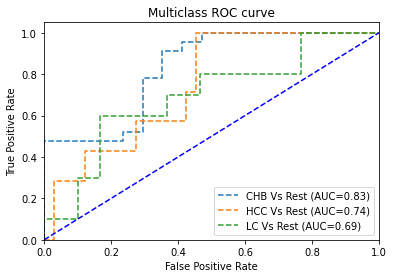

<Figure size 432x288 with 0 Axes>

In [74]:
from sklearn.preprocessing import label_binarize
#binarize the y_values
y_test_binarised=label_binarize(y_test,classes=np.unique(y_test))

#ROC curve for classes
fpr = {}
tpr = {}
thresh = {}
roc_auc = dict()

n_class = classes.shape[0]

for i in range(n_class):
    fpr[i],tpr[i],thresh[i] = roc_curve(y_test_binarised[:,i],pred_prob[:,i])
    roc_auc[i] = auc(fpr[i],tpr[i])
    
    #Plotting
    plt.plot(fpr[i],tpr[i],linestyle='--', label='%s Vs Rest (AUC=%0.2f)'%(classes[i],roc_auc[i]))
    
plt.plot([0,1],[0,1],'b--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.title('Multiclass ROC curve')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc='lower right')
plt.show()
plt.savefig('ROC.png',bbox_inches='tight')

In [ ]:
#Platelets and Total bilirubin 

In [75]:
data_feature=data[['Age','Gender','Platelets','TBb']]

In [76]:
data_outcome=data['Diagnosis']

In [77]:
X_train,X_test,y_train,y_test=train_test_split(data_feature,data_outcome,test_size=0.3)

In [ ]:
RF=OneVsRestClassifier(RandomForestClassifier(max_features=0.2))
RF.fit(X_train,y_train)
y_pred=RF.predict(X_test)
pred_prob=RF.predict_proba(X_test)

In [78]:
RF=OneVsRestClassifier(RandomForestClassifier(max_features=0.2))
RF.fit(X_train,y_train)
y_pred=RF.predict(X_test)
pred_prob=RF.predict_proba(X_test)

OneVsRestClassifier(estimator=RandomForestClassifier(max_features=0.2))

In [79]:
classes=np.unique(y_test)

(0.0, 1.0)

(0.0, 1.05)

Text(0.5, 1.0, 'Multiclass ROC curve')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 0, 'False Positive Rate')

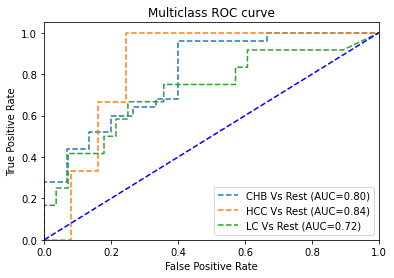

<Figure size 432x288 with 0 Axes>

In [80]:
from sklearn.preprocessing import label_binarize
#binarize the y_values
y_test_binarised=label_binarize(y_test,classes=np.unique(y_test))

#ROC curve for classes
fpr = {}
tpr = {}
thresh = {}
roc_auc = dict()

n_class = classes.shape[0]

for i in range(n_class):
    fpr[i],tpr[i],thresh[i] = roc_curve(y_test_binarised[:,i],pred_prob[:,i])
    roc_auc[i] = auc(fpr[i],tpr[i])
    
    #Plotting
    plt.plot(fpr[i],tpr[i],linestyle='--', label='%s Vs Rest (AUC=%0.2f)'%(classes[i],roc_auc[i]))
    
plt.plot([0,1],[0,1],'b--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.title('Multiclass ROC curve')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc='lower right')
plt.show()
plt.savefig('ROC.png',bbox_inches='tight')